In [1]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import scipy
import os

import seaborn as sns
import matplotlib.pyplot as plt

# Carga de datos

## Datos B/manga (Colombia)

In [2]:

# URL base de la API
base_url_ws_col = "https://www.datos.gov.co/resource/57ur-5p28.csv"

# Parámetros
limit = 1000  # número máximo permitido por la API
offset = 0    # desplazamiento inicial
all_data = [] # lista para almacenar los bloques

csv_file_ws_col = "..\\data\\datos_eh_bcmga_2021.csv"


In [3]:
if os.path.exists(csv_file_ws_col):
    ws_col = pd.read_csv(csv_file_ws_col)
    print("Se carga el archivo csv")
else:
    while True:
        # Construir URL con paginación
        url = f"{base_url_ws_col}?$limit={limit}&$offset={offset}"
        print(f"Descargando: {url}")

        # Hacer la solicitud
        response = requests.get(url)
        
        # Si falla la solicitud, salir
        if response.status_code != 200:
            print(f"Error en la descarga: {response.status_code}")
            break

        # Leer el bloque como DataFrame
        df_chunk = pd.read_csv(StringIO(response.text))
        
        # Si el bloque está vacío, terminamos
        if df_chunk.empty:
            break
        
        # Agregar a la lista
        all_data.append(df_chunk)
        
        # Aumentar el offset para el siguiente bloque
        offset += limit
    # Unir todos los bloques en un solo DataFrame
    ws_col = pd.concat(all_data, ignore_index=True)

    print(f"Total de registros descargados: {len(ws_col)}")

    ws_col.to_csv(csv_file_ws_col, index=False)


Descargando: https://www.datos.gov.co/resource/57ur-5p28.csv?$limit=1000&$offset=0
Descargando: https://www.datos.gov.co/resource/57ur-5p28.csv?$limit=1000&$offset=1000
Descargando: https://www.datos.gov.co/resource/57ur-5p28.csv?$limit=1000&$offset=2000
Descargando: https://www.datos.gov.co/resource/57ur-5p28.csv?$limit=1000&$offset=3000
Descargando: https://www.datos.gov.co/resource/57ur-5p28.csv?$limit=1000&$offset=4000
Descargando: https://www.datos.gov.co/resource/57ur-5p28.csv?$limit=1000&$offset=5000
Descargando: https://www.datos.gov.co/resource/57ur-5p28.csv?$limit=1000&$offset=6000
Descargando: https://www.datos.gov.co/resource/57ur-5p28.csv?$limit=1000&$offset=7000
Descargando: https://www.datos.gov.co/resource/57ur-5p28.csv?$limit=1000&$offset=8000
Descargando: https://www.datos.gov.co/resource/57ur-5p28.csv?$limit=1000&$offset=9000
Descargando: https://www.datos.gov.co/resource/57ur-5p28.csv?$limit=1000&$offset=10000
Descargando: https://www.datos.gov.co/resource/57ur-5p28

## Datos Bruselas (Belgica)

In [4]:
url_bel = "https://zenodo.org/records/10723261/files/Weather_data.mat"
mat_file_ws_bel = "..\\data\\Weather_data.mat"

In [5]:
if os.path.exists(mat_file_ws_bel):
    WS_data = scipy.io.loadmat(mat_file_ws_bel)
    print("Se carga el archivo mat")

else:

    response = requests.get(url_bel)
    # Verificar que la descarga fue exitosa
    if response.status_code == 200:
        with open(mat_file_ws_bel, "wb") as f:
            f.write(response.content)
        print(f"Archivo guardado como: {mat_file_ws_bel}")
        WS_data = scipy.io.loadmat(mat_file_ws_bel)
        print("Se carga el archivo mat")
    else:
        print(f"Error al descargar: {response.status_code}")

Archivo guardado como: ..\data\Weather_data.mat
Se carga el archivo mat


In [6]:
# # Extract data from dataset

# WS_data = scipy.io.loadmat(mat_file_ws_bel)
# WS_data.keys()

In [7]:
columns = ['Date', 'Lon', 'Lat', 'Alt', 'Temperature', 
           'WindSpeed', 'WindDirectionX', 'WindDirectionY', 'Pressure']

In [8]:
# Crear el DataFrame
ws_bel = pd.DataFrame({col: WS_data[col].flatten() for col in columns})

# Exploración de los datos

## Datos B/manga

Reporte de datos Estaciones Hidrometeorológicas
Ambiente y Desarrollo Sostenible
Reporte de datos Estaciones Hidrometeorológicas durante el año 2021 en el area de jurisdicción de la Corporación Autonoma Regional para la Defensa de la Meseta de Bucaramanga CDMB

In [9]:
ws_col.head()

,estaci_n,tipo,coordenada_x,coordenada_y,date,time,out,hum,speed,dir,bar,rain,rad,index
0,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T00:00:00.000,22.1,98.0,0.0,SE,676.0,0.0,0.0,-999.0
1,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T01:00:00.000,20.3,96.0,0.4,SE,676.2,5.2,0.0,-999.0
2,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T02:00:00.000,20.1,99.0,0.4,WSW,675.8,25.6,0.0,-999.0
3,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T03:00:00.000,19.6,99.0,0.4,SSE,675.6,6.0,0.0,-999.0
4,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T04:00:00.000,19.8,99.0,0.0,SSE,675.9,0.2,0.0,-999.0


### Preprocesamiento

In [10]:
# Copia del df original
df_col = ws_col.copy()

En la columna `dir` se cambia los valores cardinales a grados

In [11]:
cardinal_to_deg = {
    "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5,
    "E": 90, "ESE": 112.5, "SE": 135, "SSE": 157.5,
    "S": 180, "SSW": 202.5, "SW": 225, "WSW": 247.5,
    "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5
}


In [12]:

# Normalizar a string para detectar cardinales
df_col['dir'] = df_col['dir'].astype(str).str.strip().str.upper()

# Convertir cardinales a grados
df_col['dir_deg'] = df_col['dir'].map(cardinal_to_deg)

# Si no es cardinal, intentar convertir a número
df_col['dir_deg'] = df_col['dir_deg'].fillna(pd.to_numeric(df_col['dir'], errors='coerce'))

# Reemplazar valores inválidos
df_col['dir_deg'] = df_col['dir_deg'].replace([-999, -999.0], np.nan)

# Si hay valores > 360, llevarlos al rango [0,360)
df_col['dir_deg'] = df_col['dir_deg'] % 360

Se arregla la columna `bar` que indica la presión registrada

In [13]:
# Reemplazar valores inválidos
df_col['bar'] = df_col['bar'].replace([-999, -999.0], np.nan)

Se arregla la columna `speed` que indica la velocidad del viento registrada

In [14]:
(df_col["speed"].value_counts() / df_col.shape[0]).apply(lambda a: f"{100 * a:.2f} %")

speed
 0.000      32.23 %
-999.000    17.57 %
 0.400      11.99 %
 0.900       6.94 %
 1.300       4.53 %
             ...   
 1.148       0.00 %
 1.472       0.00 %
 1.252       0.00 %
 0.633       0.00 %
 1.525       0.00 %
Name: count, Length: 874, dtype: object

Se toma las columnas `date` y `time` para ser combinadas y obtener la columnas `datetime`

In [15]:
# Supongamos que df_col tiene las columnas 'date' y 'time'
df_col['date'] = pd.to_datetime(df_col['date'])
df_col['time'] = pd.to_datetime(df_col['time']).dt.time  # extraer solo la hora

# Combinar
df_col['datetime'] = df_col.apply(lambda row: pd.Timestamp.combine(row['date'], row['time']), axis=1)


Se elimnan los valores `nan` del dataframe

In [16]:
df_col.shape

(138566, 16)

In [17]:
df_col = df_col.loc[
    ~ df_col["dir_deg"].isna() &
    ~ df_col["bar"].isna()
].copy()

df_col.shape

(77664, 16)

In [18]:
f"Se conserva un totla de {100 * df_col.shape[0] / ws_col.shape[0]:.2f}% de los datos originales"

'Se conserva un totla de 56.05% de los datos originales'

### Análisis estaciones

Número de estaciones registradas en Bucaramanga

In [19]:
print(f"Número de estaciones: {df_col['estaci_n'].nunique()}")

Número de estaciones: 14


Se crea `ubi_ws_col` que contendra la ubicación de las estaciones por medio de coordenadas $(x, y)$, además del promedio resitrado de las columnas `speed` (velocidad) y `bar` (presión).

In [20]:
ubi_ws_col = df_col.groupby("estaci_n").agg(
    coor_x=("coordenada_x", "first"),
    coor_y=("coordenada_y", "first"),
    speed=("speed", "mean"),
    bar=("bar", "mean"),
).reset_index()

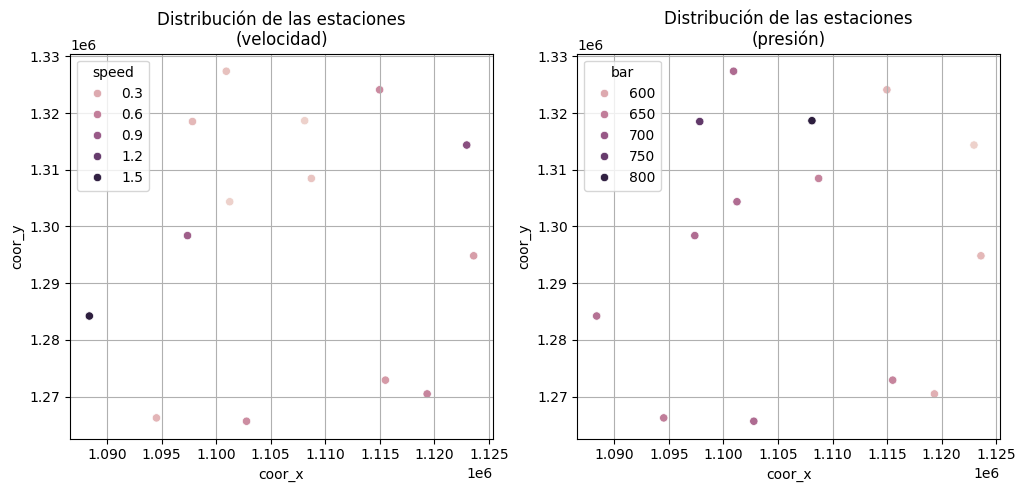

In [21]:
fig , axes = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(ubi_ws_col, x="coor_x", y="coor_y", hue="speed", ax=axes[0])
axes[0].set_title("Distribución de las estaciones\n(velocidad)")
axes[0].grid()

sns.scatterplot(ubi_ws_col, x="coor_x", y="coor_y", hue="bar", ax=axes[1])
axes[1].set_title("Distribución de las estaciones\n(presión)")
axes[1].grid()

plt.show()

In [22]:
print("Listado de las estaciones:")
for estacion in df_col["estaci_n"].unique(): print("- ", estacion)

Listado de las estaciones:
-  ACAPULCO
-  BETANIA
-  EL CAIRO
-  EL DIAMANTE
-  EL PANTANO
-  EL RASGÓN
-  EL ROBLE
-  LA AGUADA
-  LA JUDIA
-  LA NARANJERA
-  LAGO ALTO
-  PORTUGAL
-  SANTA CRUZ DE LA COLINA
-  TURBAY


In [23]:
# Se crea un diccionario que almacena la información de cada estación por separado
info_estacion_col = {
    estacion: 
        df_col.loc[
            df_col["estaci_n"] == estacion, 
            df_col.columns[2:]
            ] for estacion in df_col["estaci_n"].unique()
}

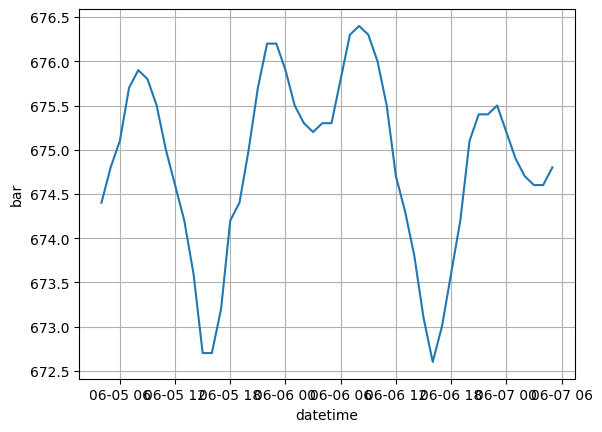

In [24]:
estacion = "ACAPULCO"
df = info_estacion_col[estacion]
df.sort_values("datetime", inplace=True)
sns.lineplot(df.iloc[100:150], x="datetime", y="bar")
plt.grid()
plt.show()

In [25]:
df_col.sort_values(by=["estaci_n", "datetime"])["datetime"].diff()

0                    NaT
1        0 days 01:00:00
2        0 days 01:00:00
3        0 days 01:00:00
4        0 days 01:00:00
               ...      
138561   0 days 01:00:00
138562   0 days 01:00:00
138563   0 days 01:00:00
138564   0 days 01:00:00
138565   0 days 01:00:00
Name: datetime, Length: 77664, dtype: timedelta64[ns]

**Nota:** Los registros en B/manga se registran con intervalos de 1h en promedio.

## Datos Bruselas

In [26]:
ws_bel.head()

,Date,Lon,Lat,Alt,Temperature,WindSpeed,WindDirectionX,WindDirectionY,Pressure
0,[2018-02-25 13:20:00],3.986000,50.501000,77.0,1.0,5.0,-0.879649,0.475624,1015.2
1,[2018-02-25 13:20:00],5.450278,50.915556,37.0,0.9,5.9,-0.956814,0.290702,1023.3
2,[2018-02-25 13:20:00],5.587500,49.620278,322.0,-0.7,5.9,-0.961262,0.275637,983.9
3,[2018-02-25 13:20:00],4.653056,50.234444,285.0,0.7,6.3,-0.771625,0.636078,989.6
4,[2018-02-25 13:20:00],6.181389,50.482222,565.1,-4.4,5.7,-0.926529,0.376224,956.3


### Preprocesamiento

In [27]:
# Copia del df original
df_bel = ws_bel.copy()

Se arregla el formato de la columna `Date`

In [28]:
df_bel["datetime"] = df_bel["Date"].apply(lambda date: date[0])
df_bel["datetime"] = pd.to_datetime(df_bel["datetime"])

Se agrega el nombre de las estaciones en una nueva columna `station`

In [29]:
df_bel.sort_values(by="Lon", inplace=True)
map_lat_station = dict(zip(df_bel["Lon"].unique() , np.array([f"station {n}" for n in range(1, 1 + df_bel["Lon"].nunique())])))

In [30]:
df_bel["station"] = df_bel["Lon"].map(map_lat_station)
df_bel.head()

,Date,Lon,Lat,Alt,Temperature,WindSpeed,WindDirectionX,WindDirectionY,Pressure,datetime,station
4810,[2018-02-27 03:30:00],2.6525,51.088056,6.1,-4.8,4.2,-0.844328,0.535827,1024.8,2018-02-27 03:30:00,station 1
27746,[2018-03-06 17:30:00],2.6525,51.088056,6.1,5.8,2.3,-0.133986,0.990983,990.5,2018-03-06 17:30:00,station 1
27738,[2018-03-06 17:20:00],2.6525,51.088056,6.1,5.8,2.9,-0.211325,0.977416,990.4,2018-03-06 17:20:00,station 1
4301,[2018-02-26 23:20:00],2.6525,51.088056,6.1,-4.6,3.3,-0.852640,0.522499,1027.0,2018-02-26 23:20:00,station 1
27700,[2018-03-06 17:10:00],2.6525,51.088056,6.1,5.8,3.0,-0.335452,0.942057,990.4,2018-03-06 17:10:00,station 1


Se elimnan los valores `nan` del dataframe

In [31]:
df_bel.shape

(42336, 11)

In [32]:
df_bel = df_bel.loc[
    ~ df_bel["WindSpeed"].isna() &
    ~ df_bel["Pressure"].isna()
].copy()

df_bel.shape

(42314, 11)

### Análisis estaciones

In [33]:
print(f"Número de estaciones: {df_bel['Lon'].nunique()}")

Número de estaciones: 21


Se crea `ubi_ws_bel` que contendra la ubicación de las estaciones por medio de coordenadas $(x, y)$, además del promedio resitrado de las columnas `speed` (velocidad) y `bar` (presión).

In [41]:
ubi_ws_bel = df_bel.groupby("station").agg(
    lon=("Lon", "first"),
    lat=("Lat", "first"),
    speed=("WindSpeed", "mean"),
    pressure=("Pressure", "mean"),
).reset_index().sort_values(by="lon")
ubi_ws_bel

,station,lon,lat,speed,pressure
0,station 1,2.652500,51.088056,5.398165,1002.198710
11,station 2,3.121667,50.903889,4.579266,1000.011756
14,station 3,3.669722,50.940556,4.631696,998.871081
15,station 4,3.815833,50.980278,4.628819,1001.455407
16,station 5,3.986000,50.501000,3.459921,991.962500
17,station 6,4.358056,50.796944,4.649129,990.591289
18,station 7,4.363889,51.324722,4.687103,1003.573958
19,station 8,4.524722,51.075000,4.093304,1002.966617
20,station 9,4.594444,50.095556,3.354167,973.897272
1,station 10,4.653056,50.234444,5.365327,968.454960


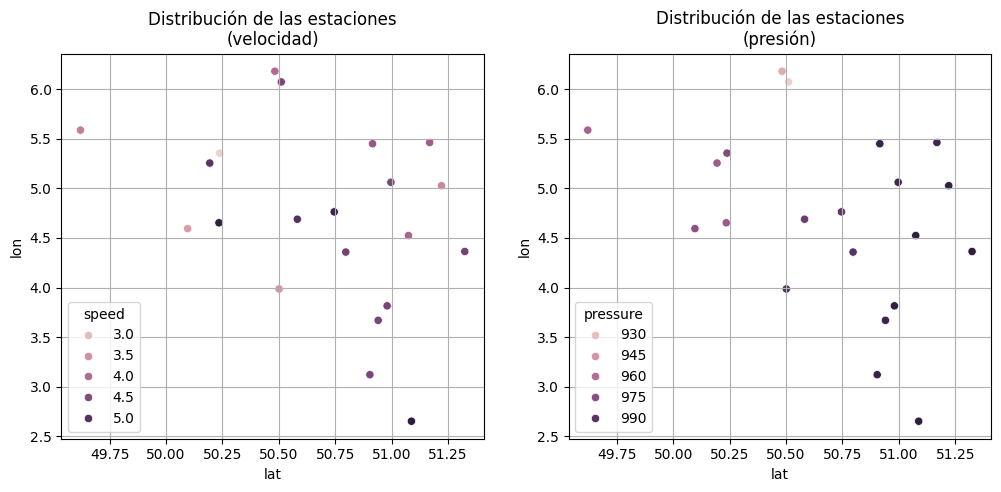

In [35]:
fig , axes = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(ubi_ws_bel, x="lat", y="lon", hue="speed", ax=axes[0])
axes[0].set_title("Distribución de las estaciones\n(velocidad)")
axes[0].grid()

sns.scatterplot(ubi_ws_bel, x="lat", y="lon", hue="pressure", ax=axes[1])
axes[1].set_title("Distribución de las estaciones\n(presión)")
axes[1].grid()

plt.show()

In [36]:
# Se crea un diccionario que almacena la información de cada estación por separado
info_estacion_bel = {
    estacion: 
        df_bel.loc[
            df_bel["station"] == estacion
            ] for estacion in df_bel["station"].unique()
}

C:\Users\User\AppData\Local\Temp\ipykernel_11840\2796833250.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values("datetime", inplace=True)


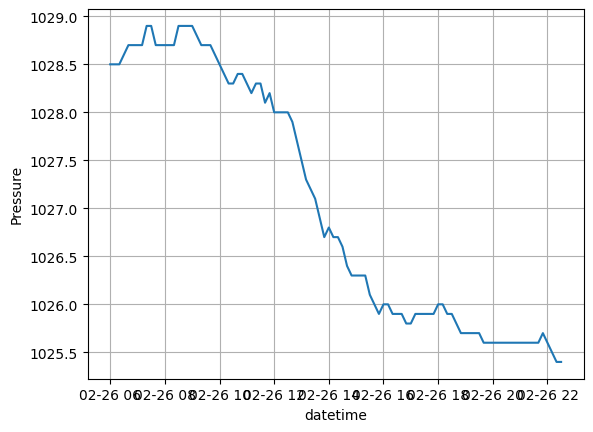

In [37]:
estacion = "station 4"
df = info_estacion_bel[estacion]
df.sort_values("datetime", inplace=True)
sns.lineplot(df.iloc[100:200], x="datetime", y="Pressure")
plt.grid()
plt.show()

In [38]:
df_bel.sort_values(by=["station", "datetime"])["datetime"].diff()

8                   NaT
26      0 days 00:10:00
45      0 days 00:10:00
67      0 days 00:10:00
99      0 days 00:10:00
              ...      
42232   0 days 00:10:00
42267   0 days 00:10:00
42275   0 days 00:10:00
42298   0 days 00:10:00
42323   0 days 00:10:00
Name: datetime, Length: 42314, dtype: timedelta64[ns]

**Nota:** Los registros en Bruselas se registran con intervalos de 10min en promedio.